# 📱 MyIM3 Google Play Review — NLP Preprocessing Pipeline
### Text Cleaning · Stopword Removal · Frequency Analysis · Visualisasi

---
**Alur kerja:**  
`Load Data` → `Eksplorasi` → `Text Cleaning` → `Stopword Removal` → `Analisis Frekuensi` → `Visualisasi`


## 📦 1. Instalasi Library

In [1]:
!pip install google_play_scraper textblob seaborn nltk -q
print("Instalasi selesai")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.2 MB/s eta 0:00:00
Instalasi selesai


## 📚 2. Import Library

In [2]:
import pandas as pd
import numpy as np
import re
import io
from collections import Counter
from pathlib import Path

import nltk
from nltk.corpus import stopwords

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ── Download NLTK resource ──
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# ── Style global ──
%matplotlib inline
%config InlineBackend.figure_format='retina'

PALETTE   = ['#1a1a2e','#16213e','#0f3460','#533483','#e94560',
             '#f5a623','#2ec4b6','#cbf3f0','#ffbf69','#ff9f1c']
BG_COLOR  = '#0d1117'
TEXT_COLOR = '#e6edf3'
ACCENT    = '#e94560'
GREEN     = '#2ec4b6'
YELLOW    = '#f5a623'

plt.rcParams.update({
    'figure.facecolor': BG_COLOR,
    'axes.facecolor'  : '#161b22',
    'axes.edgecolor'  : '#30363d',
    'axes.labelcolor' : TEXT_COLOR,
    'xtick.color'     : TEXT_COLOR,
    'ytick.color'     : TEXT_COLOR,
    'text.color'      : TEXT_COLOR,
    'grid.color'      : '#21262d',
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.5,
    'figure.figsize'  : (16, 9),
    'font.family'     : 'DejaVu Sans',
})

print("Semua library berhasil diimport!")


Semua library berhasil diimport!


## 📂 3. Upload Dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# file berupa .parquet karena kalo csv size nya besar
import pandas as pd

file_path = "/content/drive/MyDrive/dataset/hasil_crawling_myim3_versi_indonesia.parquet"

df_myim3rev = pd.read_parquet(file_path)

print(f"Berhasil memuat Parquet ({df_myim3rev.shape[0]} baris, {df_myim3rev.shape[1]} kolom)")

Berhasil memuat Parquet (2701160 baris, 11 kolom)


## 🔍 4. Eksplorasi Dataset

In [5]:
# Kolom yang ditampilkan
COLS = ['content','score','thumbsUpCount','reviewCreatedVersion','at','replyContent','repliedAt']
cols_ok = [c for c in COLS if c in df_myim3rev.columns]

print(f"Shape  : {df_myim3rev.shape}")
print(f"Kolom  : {list(df_myim3rev.columns)}")
print(f"Null   :\n{df_myim3rev[cols_ok].isnull().sum()}\n")
display(df_myim3rev[cols_ok].head(10))


Shape  : (2701160, 11)
Kolom  : ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']
Null   :
content                      27
score                         0
thumbsUpCount                 0
reviewCreatedVersion          0
at                            0
replyContent            2102474
repliedAt               2102474
dtype: int64



,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,bagus untuk di coba,5,0,82.13.0,2026-04-17 05:39:19,None,None
1,aplikasi ini sangat membantu dn kuota ny pun m...,5,0,nan,2026-04-17 05:38:08,None,None
2,"aplikasi ga guna, pulsa saya cukup tapi selalu...",1,0,82.13.1,2026-04-17 05:23:08,"Selamat sore Bapak Syaiful, maaf sebelumnya. S...",2026-04-17 09:08:05
3,ga rekomendasi,1,0,nan,2026-04-17 05:16:45,"Selamat sore Pelanggan IM3, mohon maaf atas pe...",2026-04-17 08:52:16
4,bagus,5,0,82.13.1,2026-04-17 05:00:55,None,None
5,bagus cuman kuotanya nangung' marketing semua,5,0,82.13.1,2026-04-17 04:40:32,None,None
6,gg pol,5,0,82.13.1,2026-04-17 04:29:17,None,None
7,mantap,5,0,82.13.0,2026-04-17 04:28:30,None,None
8,"fitur satspam,tapi pengguna malah di spam pop ...",2,0,82.13.0,2026-04-17 04:20:41,"Hi Kak, maaf untuk hal yang dialami. Kami akan...",2022-06-04 19:35:43
9,sangat bagus,5,0,82.13.1,2026-04-17 04:19:10,None,None


### 📊 Distribusi Rating (Score)

/tmp/ipykernel_54422/1124208656.py:29: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54422/1124208656.py:30: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('dist_score.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


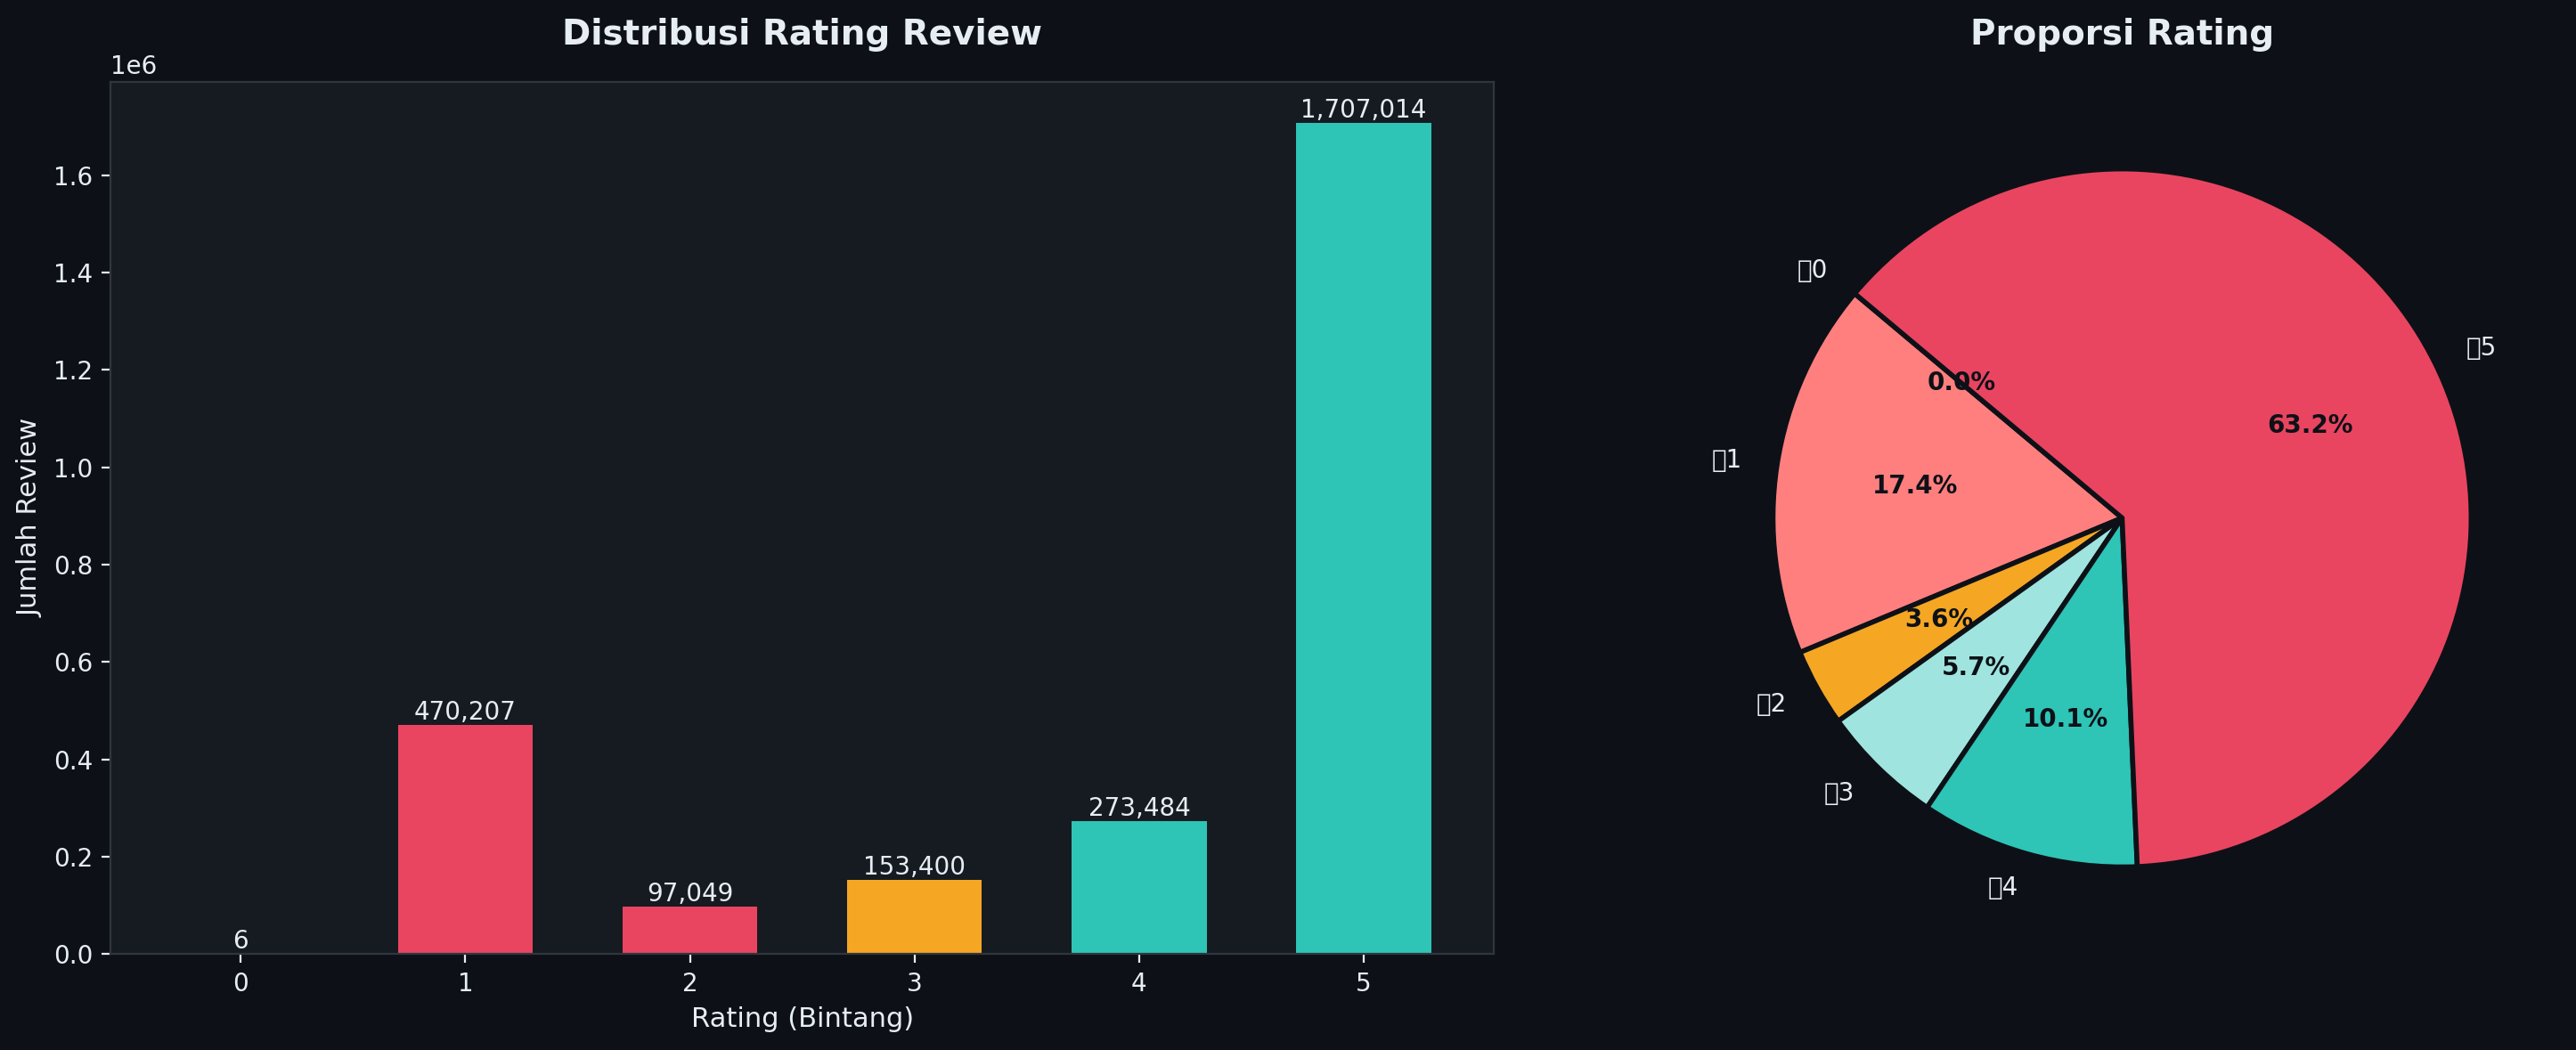


  Rating |   Jumlah |      %
----------------------------
         |        6 |   0.0%
       ⭐ |  470,207 |  17.4%
      ⭐⭐ |   97,049 |   3.6%
     ⭐⭐⭐ |  153,400 |   5.7%
    ⭐⭐⭐⭐ |  273,484 |  10.1%
   ⭐⭐⭐⭐⭐ | 1,707,014 |  63.2%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)

# Bar chart
score_counts = df_myim3rev['score'].value_counts().sort_index()
colors = [ACCENT if s <= 2 else YELLOW if s == 3 else GREEN for s in score_counts.index]
bars = axes[0].bar(score_counts.index, score_counts.values, color=colors,
                   edgecolor='none', width=0.6)
axes[0].set_title('Distribusi Rating Review', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Rating (Bintang)', fontsize=11)
axes[0].set_ylabel('Jumlah Review', fontsize=11)
for bar, val in zip(bars, score_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10, color=TEXT_COLOR)

# Pie chart
pie_colors = [ACCENT, '#ff7f7f', YELLOW, '#9fe4df', GREEN]
wedges, texts, autotexts = axes[1].pie(
    score_counts.values, labels=[f'⭐{i}' for i in score_counts.index],
    autopct='%1.1f%%', colors=pie_colors, startangle=140,
    wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 2},
    textprops={'color': TEXT_COLOR})
for at in autotexts:
    at.set_fontsize(10)
    at.set_color(BG_COLOR)
    at.set_fontweight('bold')
axes[1].set_title('Proporsi Rating', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('dist_score.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()
print(f"\n{'Rating':>8} | {'Jumlah':>8} | {'%':>6}")
print('-'*28)
for sc, cnt in score_counts.items():
    print(f"{'⭐'*sc:>8} | {cnt:>8,} | {cnt/len(df_myim3rev)*100:>5.1f}%")


## 🧹 5. Text Cleaning (Normalisasi Teks)

Tahap pembersihan teks sebelum stopword removal:
1. **Lowercase** — semua huruf kecil  
2. **Hapus URL** — link tidak relevan  
3. **Hapus mention & hashtag** — @user, #tag  
4. **Hapus karakter non-huruf** — angka, tanda baca, emoji  
5. **Normalisasi spasi** — spasi ganda dihapus  


In [7]:
def clean_text(text: str) -> str:
    """Pipeline pembersihan teks dasar."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # hapus URL
    text = re.sub(r'@\w+|#\w+', ' ', text)                  # hapus mention/hashtag
    text = re.sub(r'[^a-z\s]', ' ', text)                    # hapus non-huruf
    text = re.sub(r'\s+', ' ', text).strip()                 # normalisasi spasi
    return text

# Terapkan ke kolom content
df_myim3rev['content_clean'] = df_myim3rev['content'].apply(clean_text)

# Preview hasil cleaning
print("Contoh hasil cleaning:")
print("-"*60)
for i in range(3):
    orig  = str(df_myim3rev['content'].iloc[i])[:80]
    clean = str(df_myim3rev['content_clean'].iloc[i])[:80]
    print(f"  ASLI  : {orig}")
    print(f"  BERSIH: {clean}")
    print()

# Statistik panjang teks
df_myim3rev['len_original'] = df_myim3rev['content'].astype(str).str.len()
df_myim3rev['len_clean']    = df_myim3rev['content_clean'].str.len()
print(f"Rata-rata panjang ASLI  : {df_myim3rev['len_original'].mean():.1f} karakter")
print(f"Rata-rata panjang BERSIH: {df_myim3rev['len_clean'].mean():.1f} karakter")


Contoh hasil cleaning:
------------------------------------------------------------
  ASLI  : bagus untuk di coba
  BERSIH: bagus untuk di coba

  ASLI  : aplikasi ini sangat membantu dn kuota ny pun mura mura🤝
  BERSIH: aplikasi ini sangat membantu dn kuota ny pun mura mura

  ASLI  : aplikasi ga guna, pulsa saya cukup tapi selalu gagal beli data, dan layanan chat
  BERSIH: aplikasi ga guna pulsa saya cukup tapi selalu gagal beli data dan layanan chat i

Rata-rata panjang ASLI  : 39.1 karakter
Rata-rata panjang BERSIH: 37.4 karakter


## 🚫 6. Stopword Removal

### 6a. Load NLTK Indonesian Stopwords

In [8]:
indonesian_stopwords = set(stopwords.words('indonesian'))
print(f"Jumlah stopwords NLTK Indonesia: {len(indonesian_stopwords)}")
print("\nContoh:", sorted(list(indonesian_stopwords))[:20])


Jumlah stopwords NLTK Indonesia: 757

Contoh: ['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara']


### 6b. Custom Stopwords Tambahan

Kata-kata di bawah **tidak ada di NLTK** namun tidak bermakna dalam analisis sentimen.  
Dikelompokkan berdasarkan jenis:


In [9]:
custom_stopwords = {
    'ga', 'gak', 'gk', 'ngga', 'nggak', 'nggk', 'kagak', 'enggak',
    'ya','ok','im','oke','gua','gw','mulu',

    'aja', 'doang', 'sih', 'dong', 'deh', 'nih', 'loh', 'nah',
    'yah', 'wah', 'mah', 'tuh', 'kan', 'kok',

    'udah', 'udh', 'dah', 'sdh', 'blm', 'belom',
    'emang', 'memang', 'kayak', 'kaya', 'kek', 'gitu', 'gini',
    'bgt','beli', 'kasih', 'bintang', 'masuk', 'buka', 'isi',
    'cek', 'semoga', 'mohon', 'terimakasih', 'makasih','pake','kali', 'main', 'terima', 'bikin', 'coba',
    'dapet', 'ganti', 'gimana','kadang', 'daerah', 'pengguna', 'download',
    'rb','harga', 'promo', 'gratis', 'bonus', 'game','hilang','ilang','tolong',

    'yg',
    'dgn', 'dg', 'krn', 'karna', 'utk', 'tdk', 'hrs',
    'tp', 'tpi', 'ttg', 'dr', 'pd', 'dlm', 'sm', 'jd', 'jdi',
    'lg', 'lgi', 'jg', 'juga', 'sdg', 'spy', 'bnyk', 'byk',

    'myim3', 'im3', 'app', 'aplikasi', 'appnya', 'aplikasinya',
    'apk', 'apknya','myim','indosat','my', 'gb', 'kartu', 'data', 'internet', 'aplikasi', 'paket', 'pulsa', 'kuota','kouta','jaringan','jaringannya','pakai','sinyal','sinyalnya','paketan','signal',

    'kalo', 'kalau', 'klo', 'klu', 'sama', 'pas', 'buat',
    'biar', 'supaya', 'terus', 'trus', 'habis', 'abis', 'abisnya',
    'banget', 'sangat',

    'ada', 'itu', 'ini', 'nya', 'yang', 'di', 'ke', 'dari',
    'dengan', 'dan', 'atau', 'untuk', 'pada', 'tidak', 'bisa',
    'akan', 'juga', 'sudah', 'belum', 'bisa', 'lebih', 'lagi',
    'masih', 'seperti', 'saat', 'setelah', 'kalau', 'karena','langsung', 'update', 'pelanggan', 'hp',
    'tau', 'min', 'provider', 'sisa', 'sms', 'login', 'jam', 'operator',
    'kualitas', 'pelayanan','unlimited','mending','sy','nih','ni','ko','the', 'in', 'is', 'ny', 'ku', 'si', 'an', 'aj',
    'orang', 'kota', 'jam', 'malam', 'hujan',
    'daftar', 'kode', 'job', 'eh', 'up', 'the', 'ny', 'youtube',
    'cs', 'apl', 'apps', 'wa',

    '1', '2', '3', '4', '5', '0',
}

# Gabung NLTK + custom
all_stopwords = indonesian_stopwords.union(custom_stopwords)

# Statistik
new_only = custom_stopwords - indonesian_stopwords
print(f"Stopwords NLTK              : {len(indonesian_stopwords)}")
print(f"Custom stopwords            : {len(custom_stopwords)}")
print(f"Kata custom BARU (non-NLTK) : {len(new_only)}")
print(f"Total gabungan              : {len(all_stopwords)}")
print(f"\nKata custom baru: {sorted(new_only)}")


Stopwords NLTK              : 757
Custom stopwords            : 215
Kata custom BARU (non-NLTK) : 177
Total gabungan              : 934

Kata custom baru: ['0', '1', '2', '3', '4', '5', 'abis', 'abisnya', 'aj', 'aja', 'an', 'apk', 'apknya', 'apl', 'aplikasi', 'aplikasinya', 'app', 'appnya', 'apps', 'banget', 'beli', 'belom', 'bgt', 'biar', 'bikin', 'bintang', 'blm', 'bnyk', 'bonus', 'buka', 'byk', 'cek', 'coba', 'cs', 'daerah', 'daftar', 'dah', 'dapet', 'data', 'deh', 'dg', 'dgn', 'dlm', 'doang', 'download', 'dr', 'eh', 'emang', 'ga', 'gak', 'game', 'ganti', 'gb', 'gimana', 'gini', 'gitu', 'gk', 'gratis', 'gua', 'gw', 'habis', 'harga', 'hilang', 'hp', 'hrs', 'hujan', 'ilang', 'im', 'im3', 'in', 'indosat', 'internet', 'is', 'isi', 'jam', 'jaringan', 'jaringannya', 'jd', 'jdi', 'jg', 'job', 'kadang', 'kagak', 'kali', 'kalo', 'karna', 'kartu', 'kasih', 'kaya', 'kayak', 'kek', 'klo', 'klu', 'ko', 'kode', 'kota', 'kouta', 'krn', 'ku', 'kualitas', 'kuota', 'langsung', 'lg', 'lgi', 'login', '

## ⚙️ 7. Pipeline Preprocessing Lengkap

Fungsi `preprocess_text()` menggabungkan semua tahap:  
`clean → tokenize → filter stopwords → filter kata pendek`


In [10]:
def preprocess_text(text: str, sw_set: set, min_len: int = 2) -> list:
    """
    Full preprocessing pipeline.
    Returns: list of clean tokens
    """
    cleaned = clean_text(text)
    tokens  = cleaned.split()
    tokens  = [t for t in tokens
               if t not in sw_set       # bukan stopword
               and len(t) >= min_len    # minimal 2 huruf
               and not t.isdigit()]     # bukan angka murni
    return tokens

# Terapkan ke seluruh dataset
df_myim3rev['tokens'] = df_myim3rev['content'].apply(
    lambda x: preprocess_text(x, all_stopwords)
)

# Kolom joined untuk TF-IDF / model
df_myim3rev['content_processed'] = df_myim3rev['tokens'].apply(lambda t: ' '.join(t))

# Preview hasil
print("Contoh hasil tokenisasi:")
print("-"*70)
for i in range(5):
    orig   = str(df_myim3rev['content'].iloc[i])[:70]
    tokens = df_myim3rev['tokens'].iloc[i][:12]
    print(f"  ASLI  : {orig}")
    print(f"  TOKEN : {tokens}")
    print()

# Statistik token
df_myim3rev['token_count'] = df_myim3rev['tokens'].apply(len)
print(f"Rata-rata token per review: {df_myim3rev['token_count'].mean():.1f}")
print(f"Median token per review   : {df_myim3rev['token_count'].median():.0f}")
print(f"Review dengan 0 token     : {(df_myim3rev['token_count'] == 0).sum()}")


Contoh hasil tokenisasi:
----------------------------------------------------------------------
  ASLI  : bagus untuk di coba
  TOKEN : ['bagus']

  ASLI  : aplikasi ini sangat membantu dn kuota ny pun mura mura🤝
  TOKEN : ['membantu', 'dn', 'mura', 'mura']

  ASLI  : aplikasi ga guna, pulsa saya cukup tapi selalu gagal beli data, dan la
  TOKEN : ['gagal', 'layanan', 'chat', 'indira', 'chatbot', 'selesai', 'ylki', 'urus', 'mengabaikan', 'konsumen']

  ASLI  : ga rekomendasi
  TOKEN : ['rekomendasi']

  ASLI  : bagus
  TOKEN : ['bagus']

Rata-rata token per review: 2.4
Median token per review   : 1
Review dengan 0 token     : 340564


## 📈 8. Analisis Frekuensi Kata

In [11]:
# Flatten semua token
all_tokens = [t for tokens in df_myim3rev['tokens'] for t in tokens]
word_counts = Counter(all_tokens)
TOP_N = 30
common_words = word_counts.most_common(TOP_N)
word_freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

print(f"Total token   : {len(all_tokens):,}")
print(f"Kata unik     : {len(word_counts):,}")
print(f"\nTop {TOP_N} kata terbanyak:")
display(word_freq_df)


Total token   : 6,607,455
Kata unik     : 188,547

Top 30 kata terbanyak:


,Word,Frequency
0,bagus,412185
1,mantap,205157
2,good,123205
3,membantu,103371
4,lemot,71585
5,suka,70897
6,jelek,60334
7,puas,58097
8,keren,55986
9,mahal,50697


## 🎨 9. Visualisasi

### 9a. Top 30 Kata Paling Sering Muncul

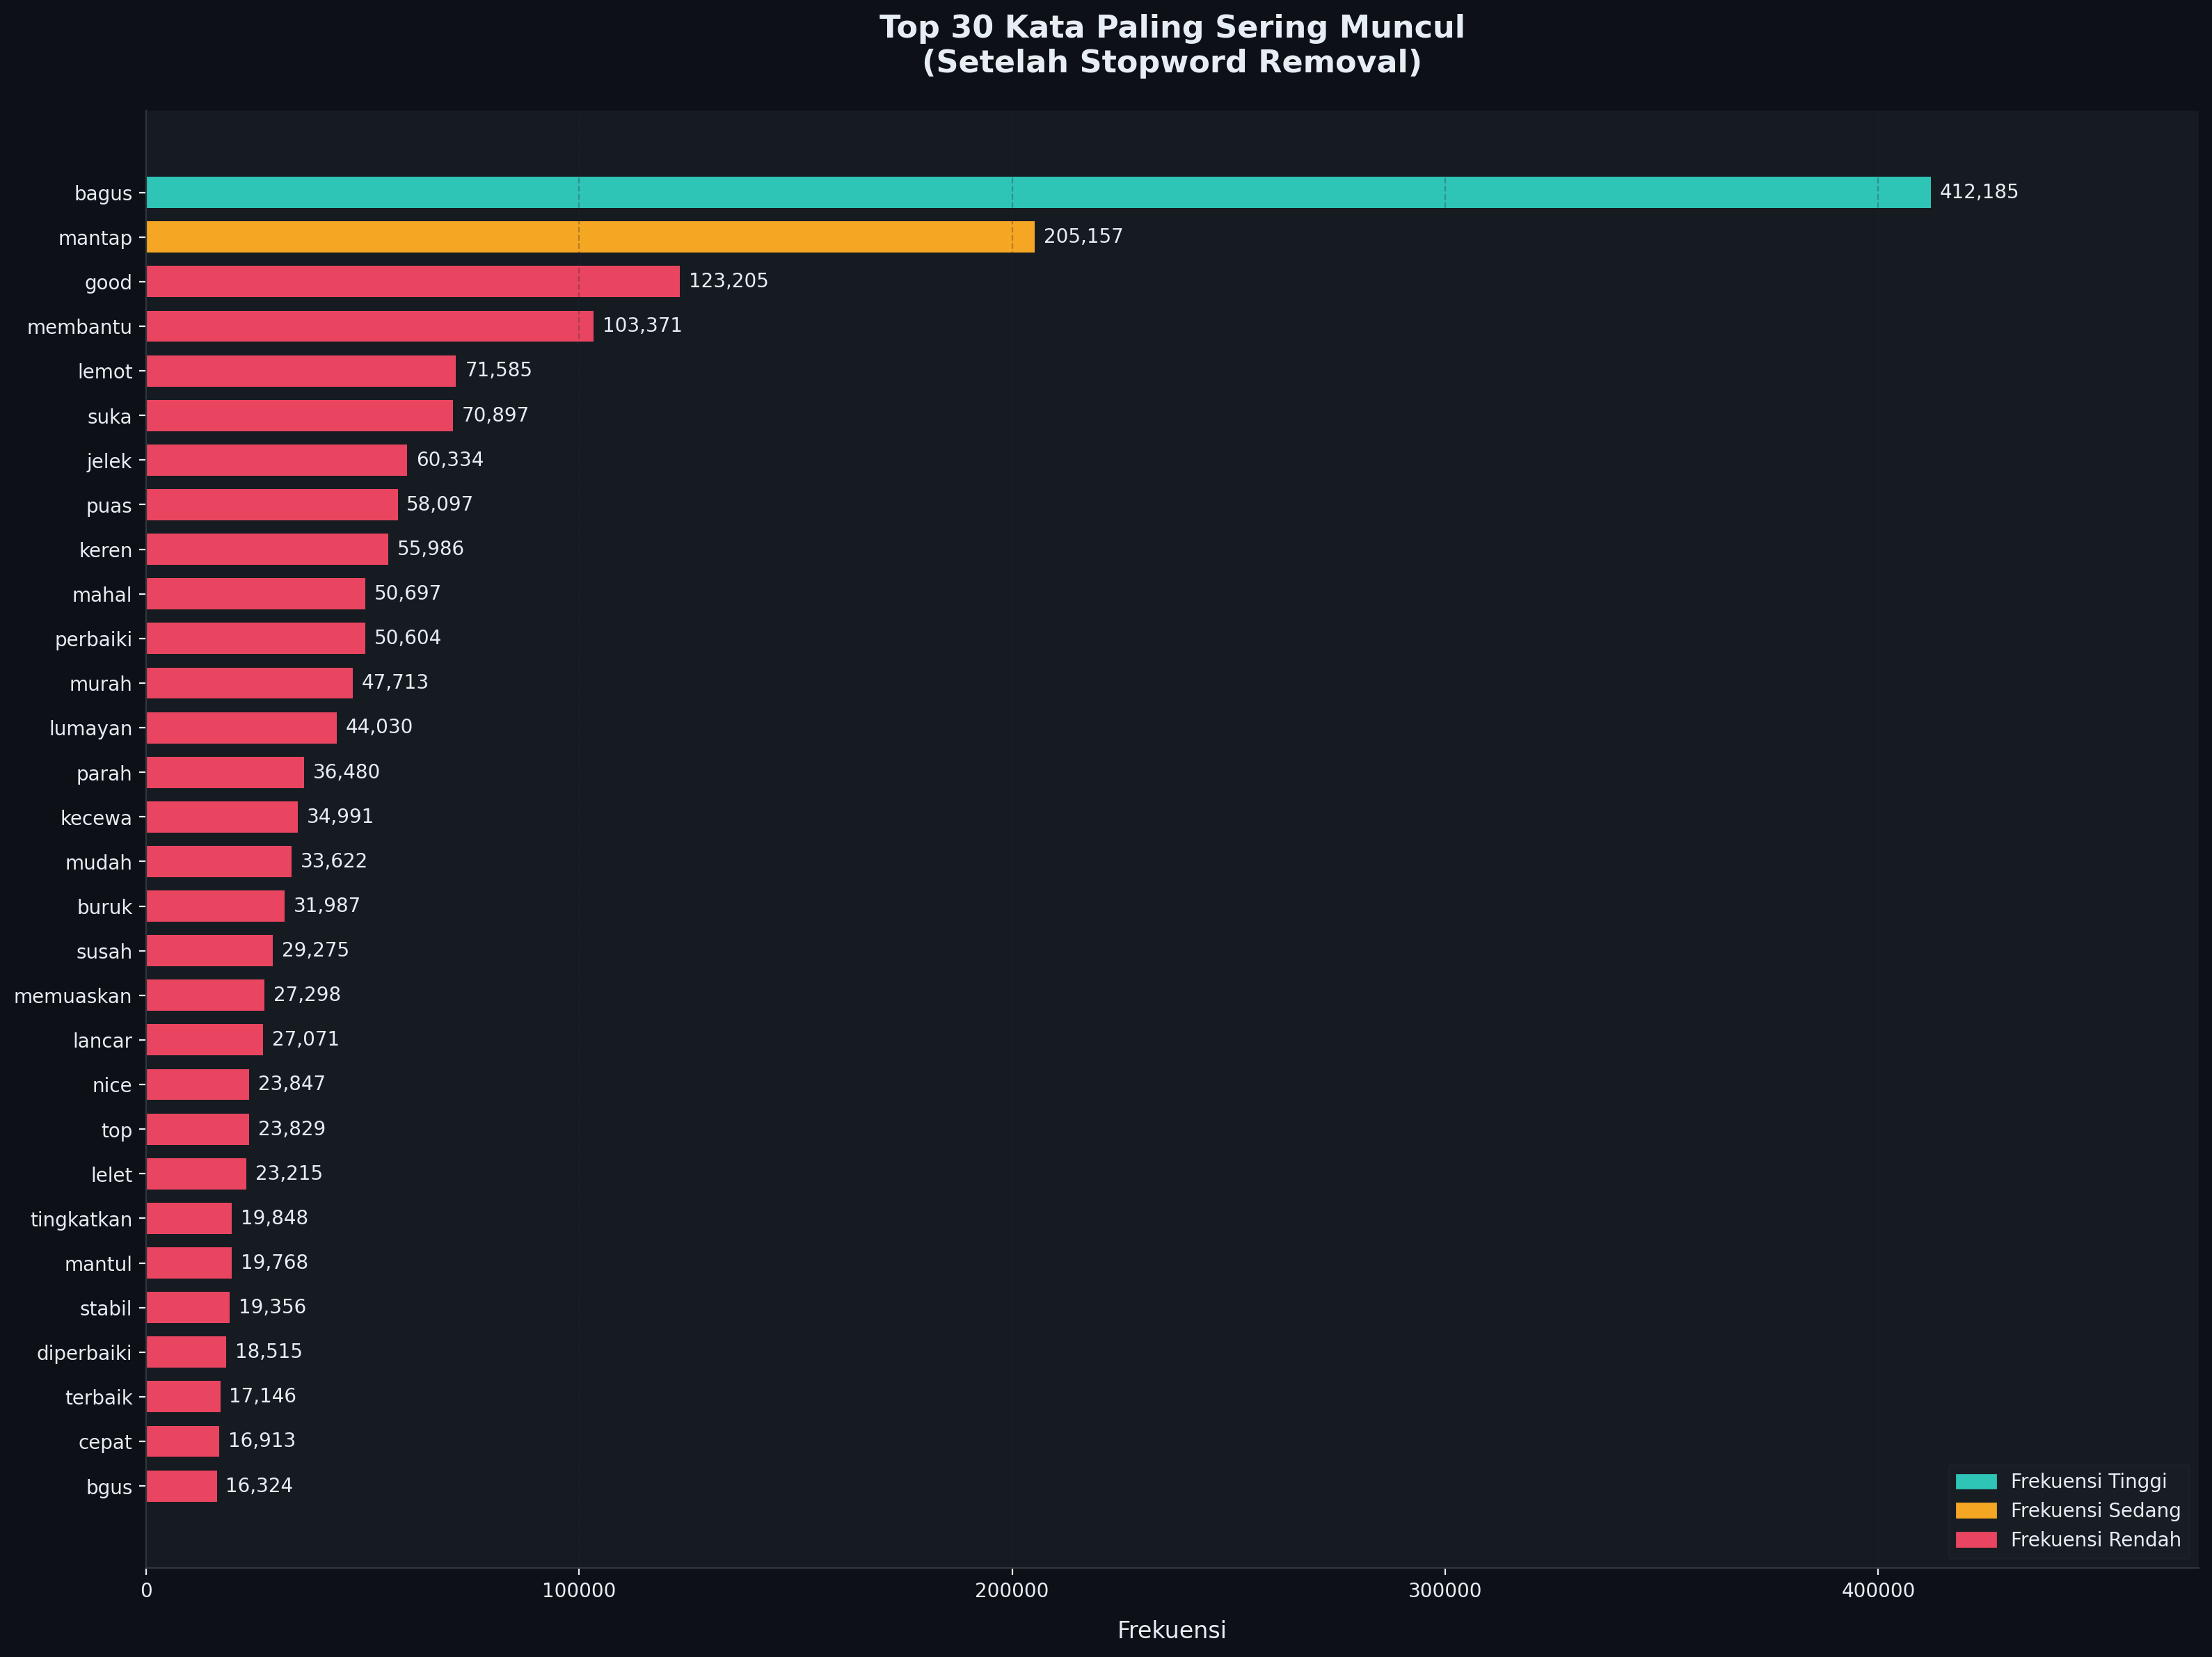

In [12]:
TOP_N = 30
top_df = word_freq_df.head(TOP_N).copy()

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor(BG_COLOR)

# Gradient warna berdasarkan frekuensi (high=green, mid=yellow, low=red)
freq_max = top_df['Frequency'].max()
colors = []
for freq in top_df['Frequency'][::-1]:
    ratio = freq / freq_max
    if ratio > 0.66:
        colors.append(GREEN)
    elif ratio > 0.33:
        colors.append(YELLOW)
    else:
        colors.append(ACCENT)

bars = ax.barh(top_df['Word'][::-1], top_df['Frequency'][::-1],
               color=colors, edgecolor='none', height=0.7)

# Label nilai di tiap bar
for bar in bars:
    w = bar.get_width()
    ax.text(w + freq_max*0.005, bar.get_y() + bar.get_height()/2,
            f'{int(w):,}', va='center', ha='left', fontsize=10, color=TEXT_COLOR)

# Styling
ax.set_xlim(0, freq_max * 1.15)
ax.set_xlabel('Frekuensi', fontsize=12, labelpad=10)
ax.set_title(f'Top {TOP_N} Kata Paling Sering Muncul\n(Setelah Stopword Removal)',
             fontsize=16, fontweight='bold', pad=20, color=TEXT_COLOR)

# Legend
legend_patches = [
    mpatches.Patch(color=GREEN,  label='Frekuensi Tinggi'),
    mpatches.Patch(color=YELLOW, label='Frekuensi Sedang'),
    mpatches.Patch(color=ACCENT, label='Frekuensi Rendah'),
]
ax.legend(handles=legend_patches, loc='lower right', framealpha=0.2,
          facecolor='#21262d', edgecolor='#30363d', labelcolor=TEXT_COLOR)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()


### 9b. Distribusi Panjang Token per Review

/tmp/ipykernel_54422/3645706141.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_box, patch_artist=True,
/tmp/ipykernel_54422/3645706141.py:33: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54422/3645706141.py:34: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('token_dist.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


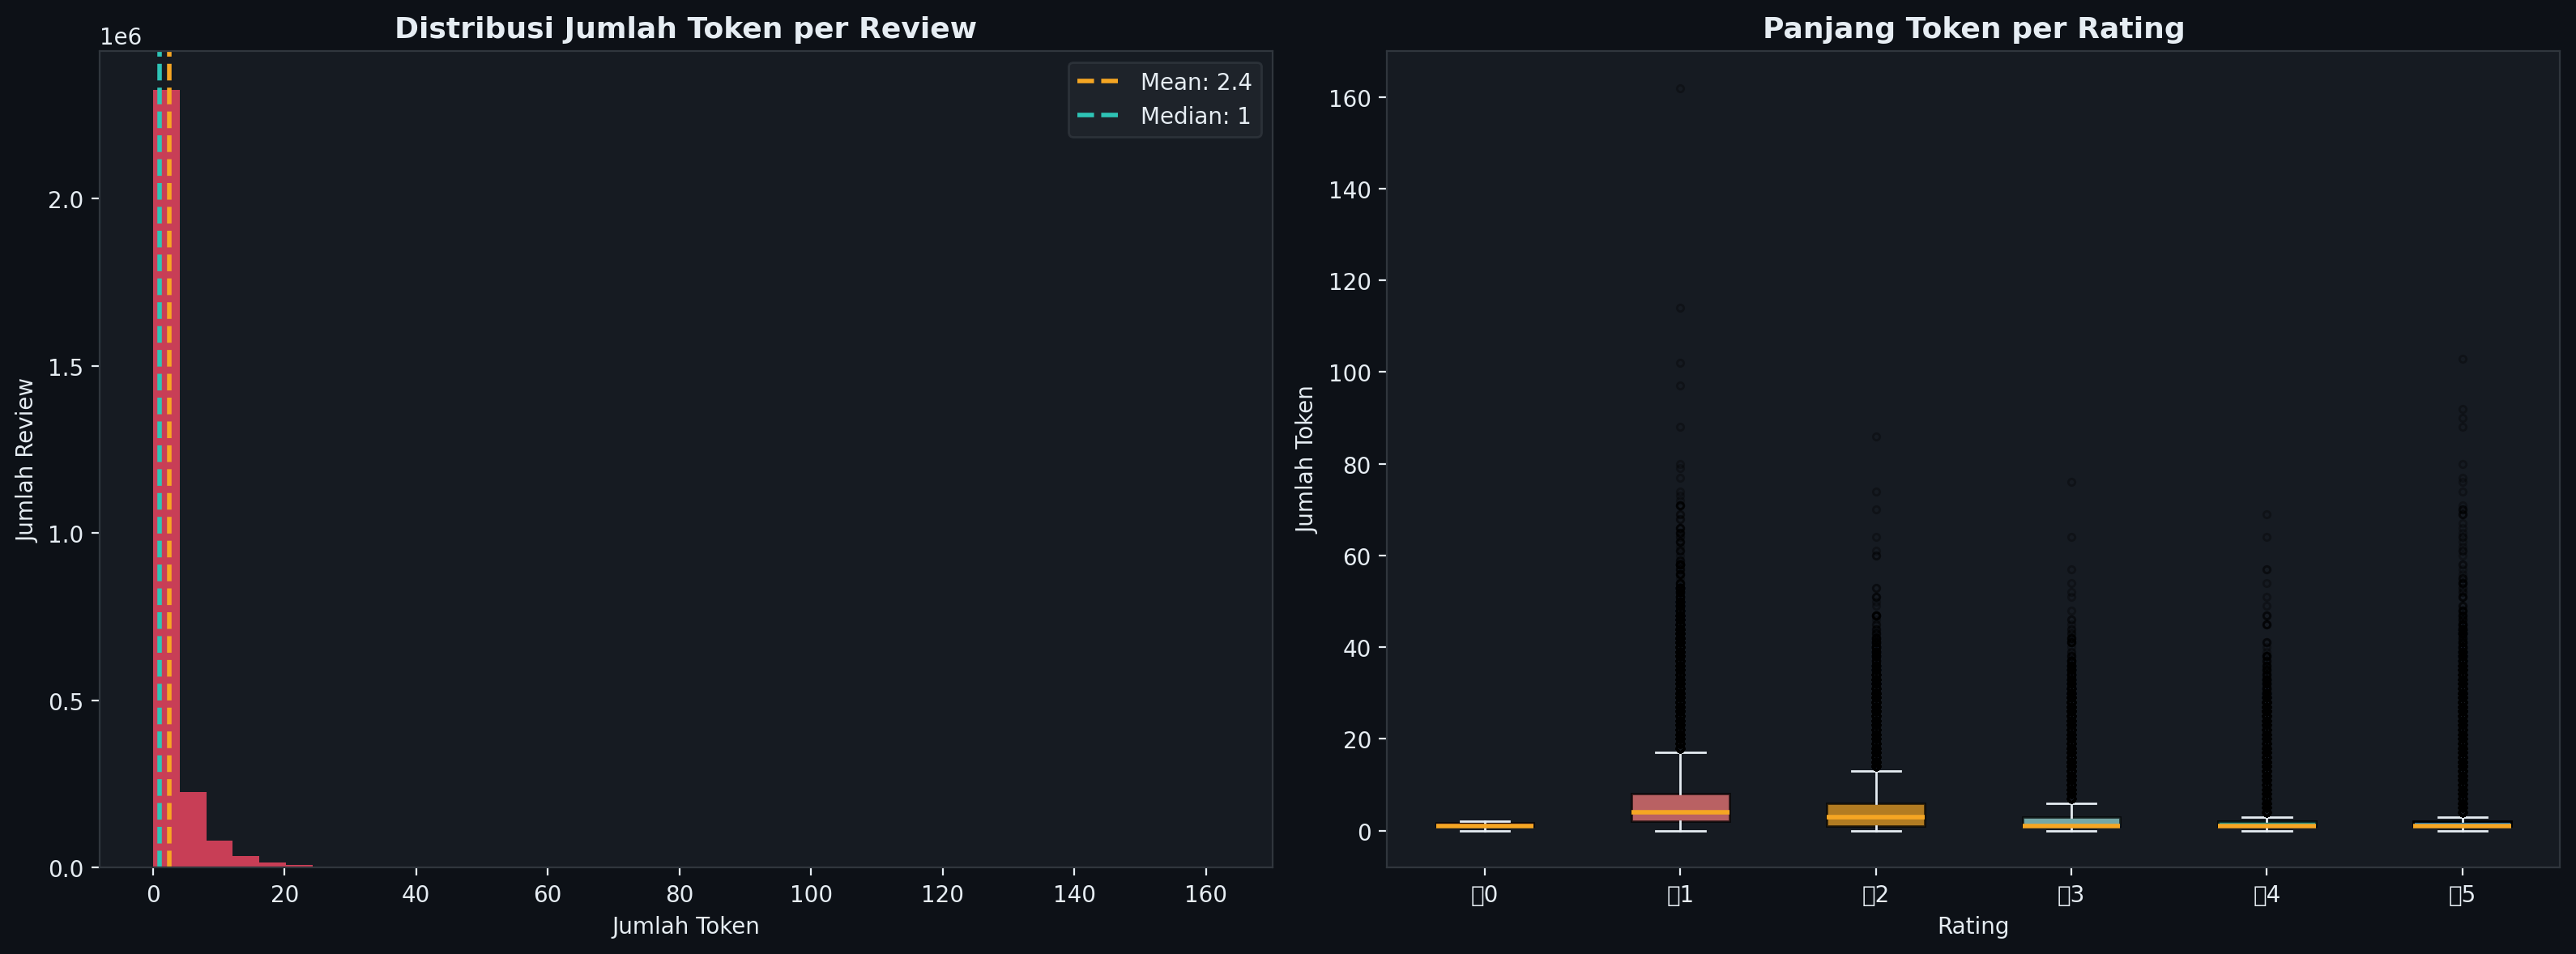

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG_COLOR)

# Histogram
axes[0].hist(df_myim3rev['token_count'], bins=40, color=ACCENT,
             edgecolor='none', alpha=0.85)
axes[0].axvline(df_myim3rev['token_count'].mean(), color=YELLOW,
                linestyle='--', linewidth=2, label=f"Mean: {df_myim3rev['token_count'].mean():.1f}")
axes[0].axvline(df_myim3rev['token_count'].median(), color=GREEN,
                linestyle='--', linewidth=2, label=f"Median: {df_myim3rev['token_count'].median():.0f}")
axes[0].set_title('Distribusi Jumlah Token per Review', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Token')
axes[0].set_ylabel('Jumlah Review')
axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor=TEXT_COLOR)

# Boxplot per score
score_order = sorted(df_myim3rev['score'].dropna().unique())
data_box = [df_myim3rev[df_myim3rev['score']==s]['token_count'].values for s in score_order]
bp = axes[1].boxplot(data_box, patch_artist=True,
                     labels=[f'⭐{int(s)}' for s in score_order],
                     medianprops={'color': YELLOW, 'linewidth': 2},
                     whiskerprops={'color': TEXT_COLOR},
                     capprops={'color': TEXT_COLOR},
                     flierprops={'marker':'o','color':ACCENT,'alpha':0.3,'markersize':3})
box_colors = [ACCENT, '#ff7f7f', YELLOW, '#9fe4df', GREEN]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Panjang Token per Rating', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah Token')

plt.tight_layout()
plt.savefig('token_dist.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()


### 9c. Heatmap Frekuensi Kata per Rating

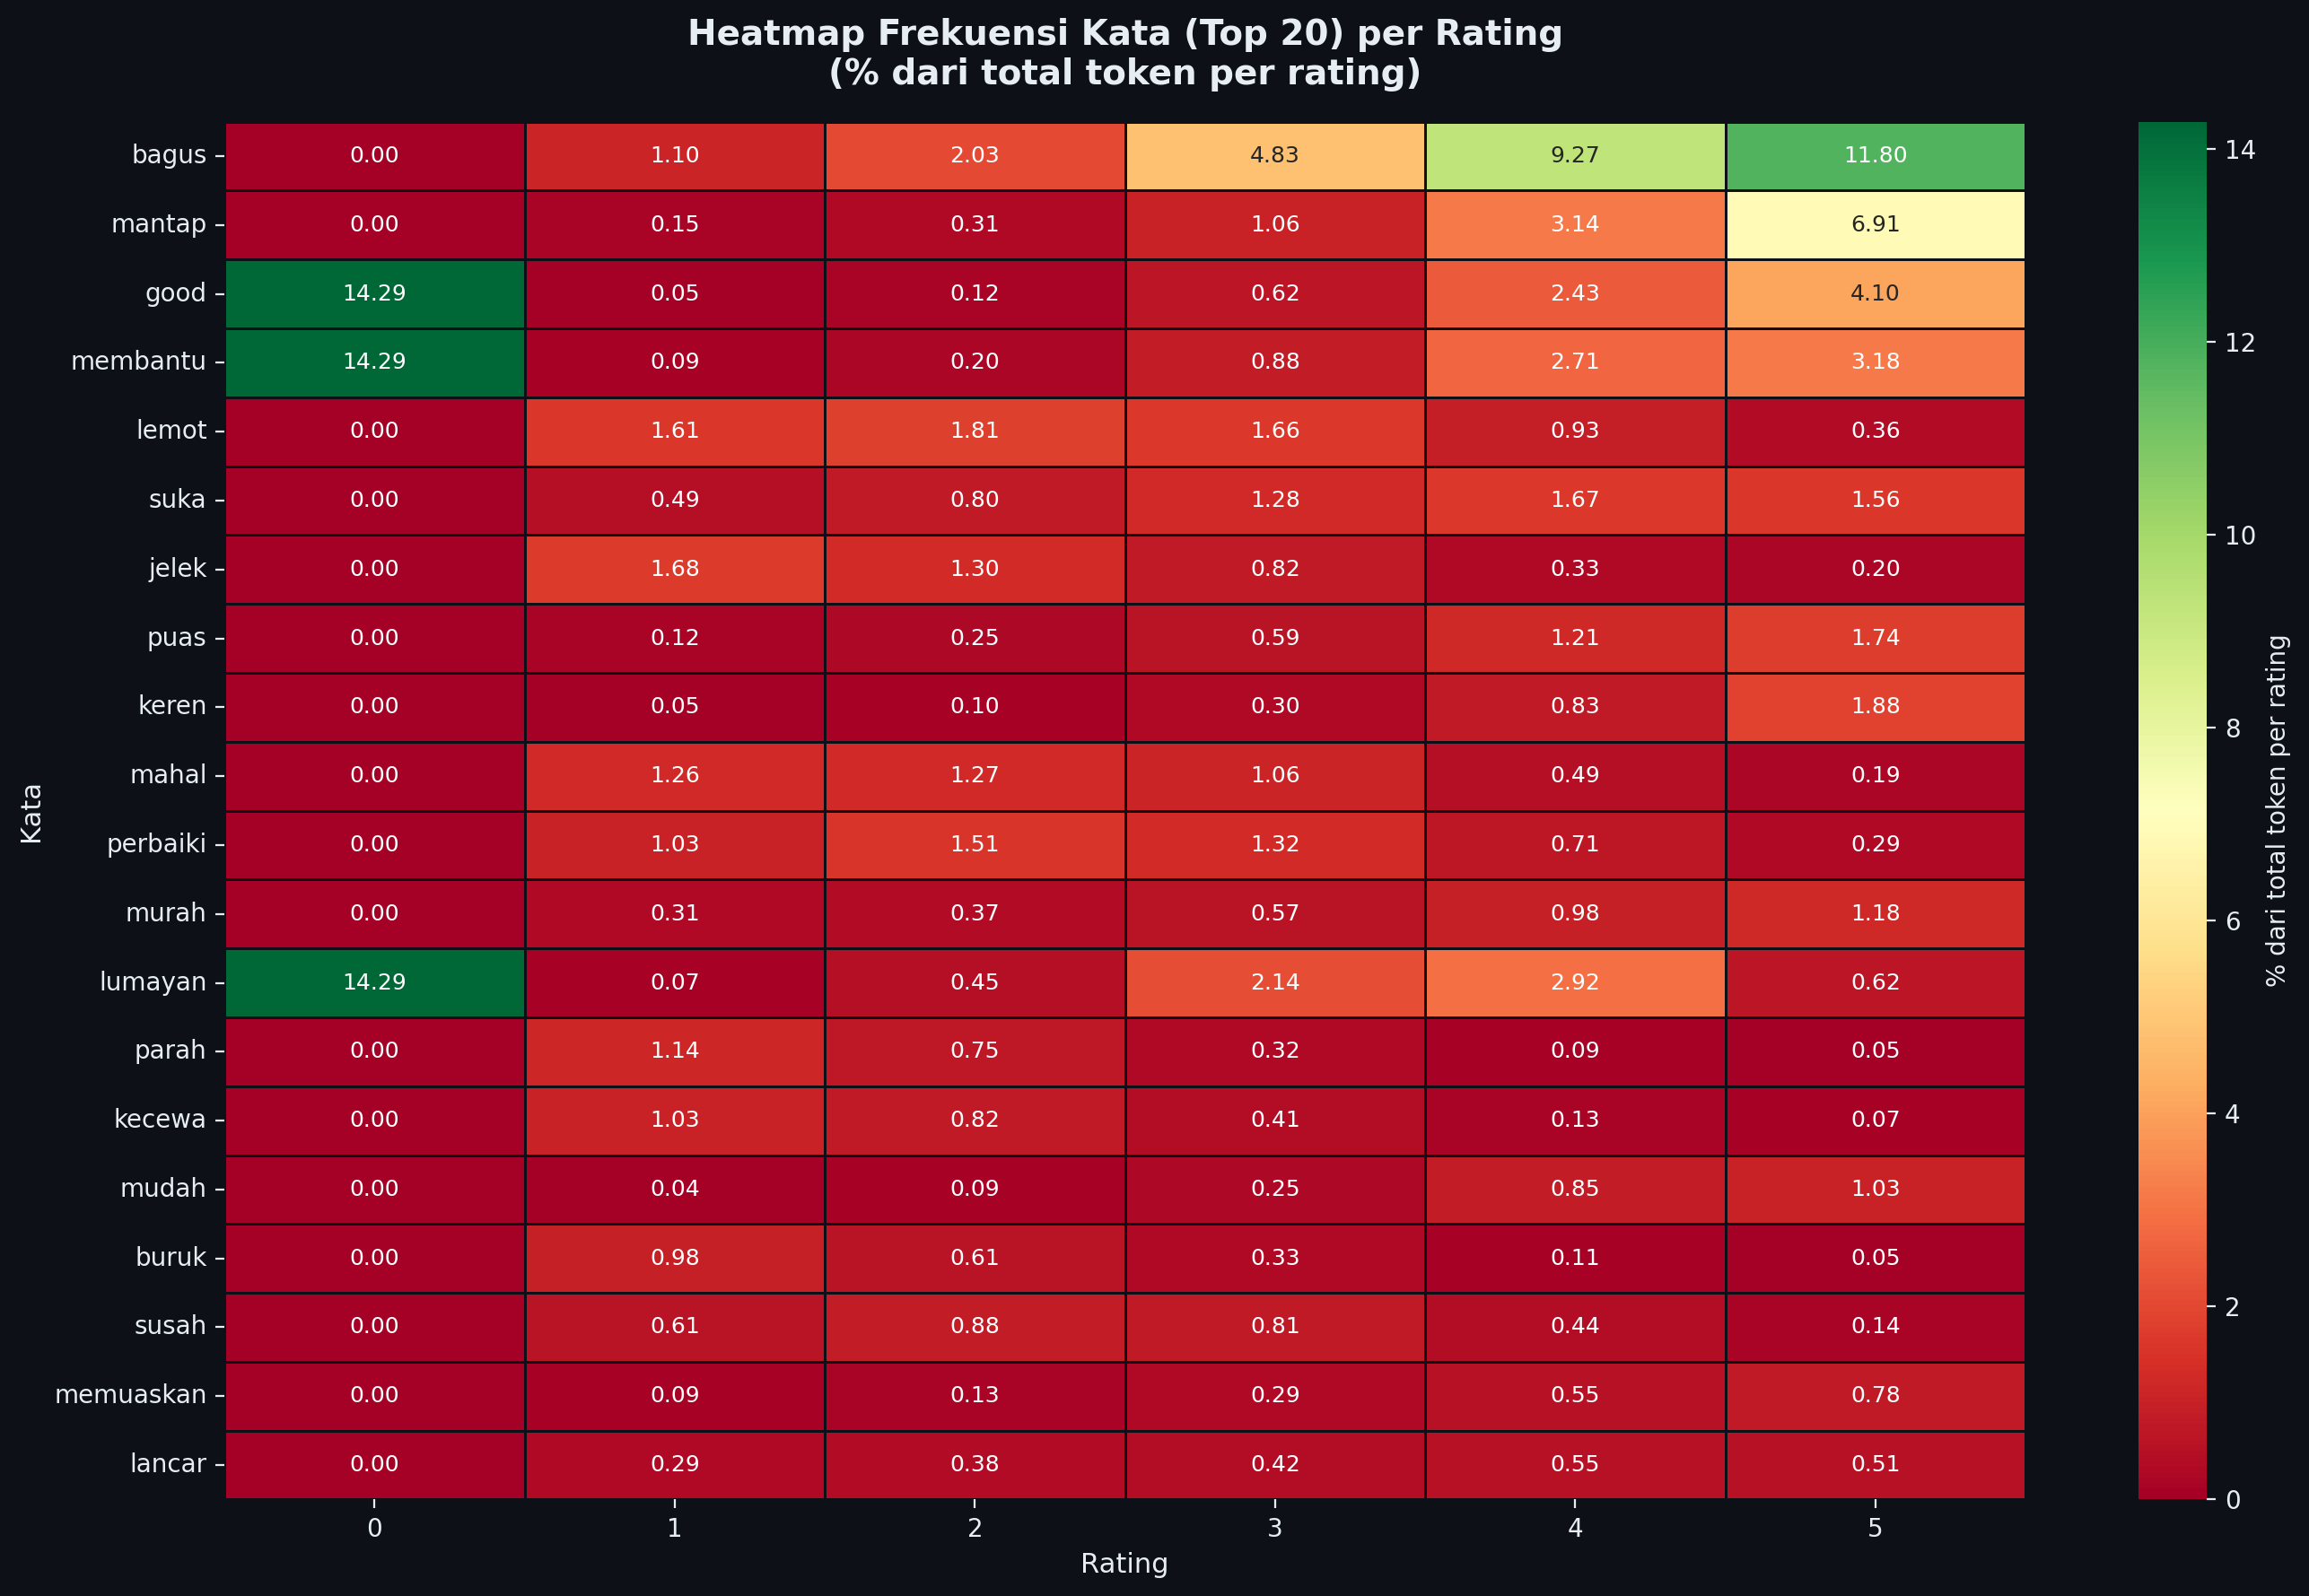

In [14]:
TOP_HEAT = 20
top_words_list = [w for w, _ in word_counts.most_common(TOP_HEAT)]

# Hitung frekuensi per score
heatmap_data = {}
for score in sorted(df_myim3rev['score'].dropna().unique()):
    subset_tokens = [t for tokens in df_myim3rev[df_myim3rev['score']==score]['tokens']
                     for t in tokens]
    cnt = Counter(subset_tokens)
    total = sum(cnt.values()) or 1
    heatmap_data[f'{int(score)}'] = [cnt.get(w, 0)/total*100 for w in top_words_list]

heat_df = pd.DataFrame(heatmap_data, index=top_words_list)

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor(BG_COLOR)
sns.heatmap(heat_df, ax=ax, cmap='RdYlGn', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#0d1117',
            cbar_kws={'label': '% dari total token per rating'},
            annot_kws={'size': 9})
ax.set_title(f'Heatmap Frekuensi Kata (Top {TOP_HEAT}) per Rating\n(% dari total token per rating)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rating', fontsize=11)
ax.set_ylabel('Kata', fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_words.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()


### 9d. Perbandingan Kata Positif vs Negatif per Rating

/tmp/ipykernel_54422/3826692343.py:44: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_54422/3826692343.py:45: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('pos_neg.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


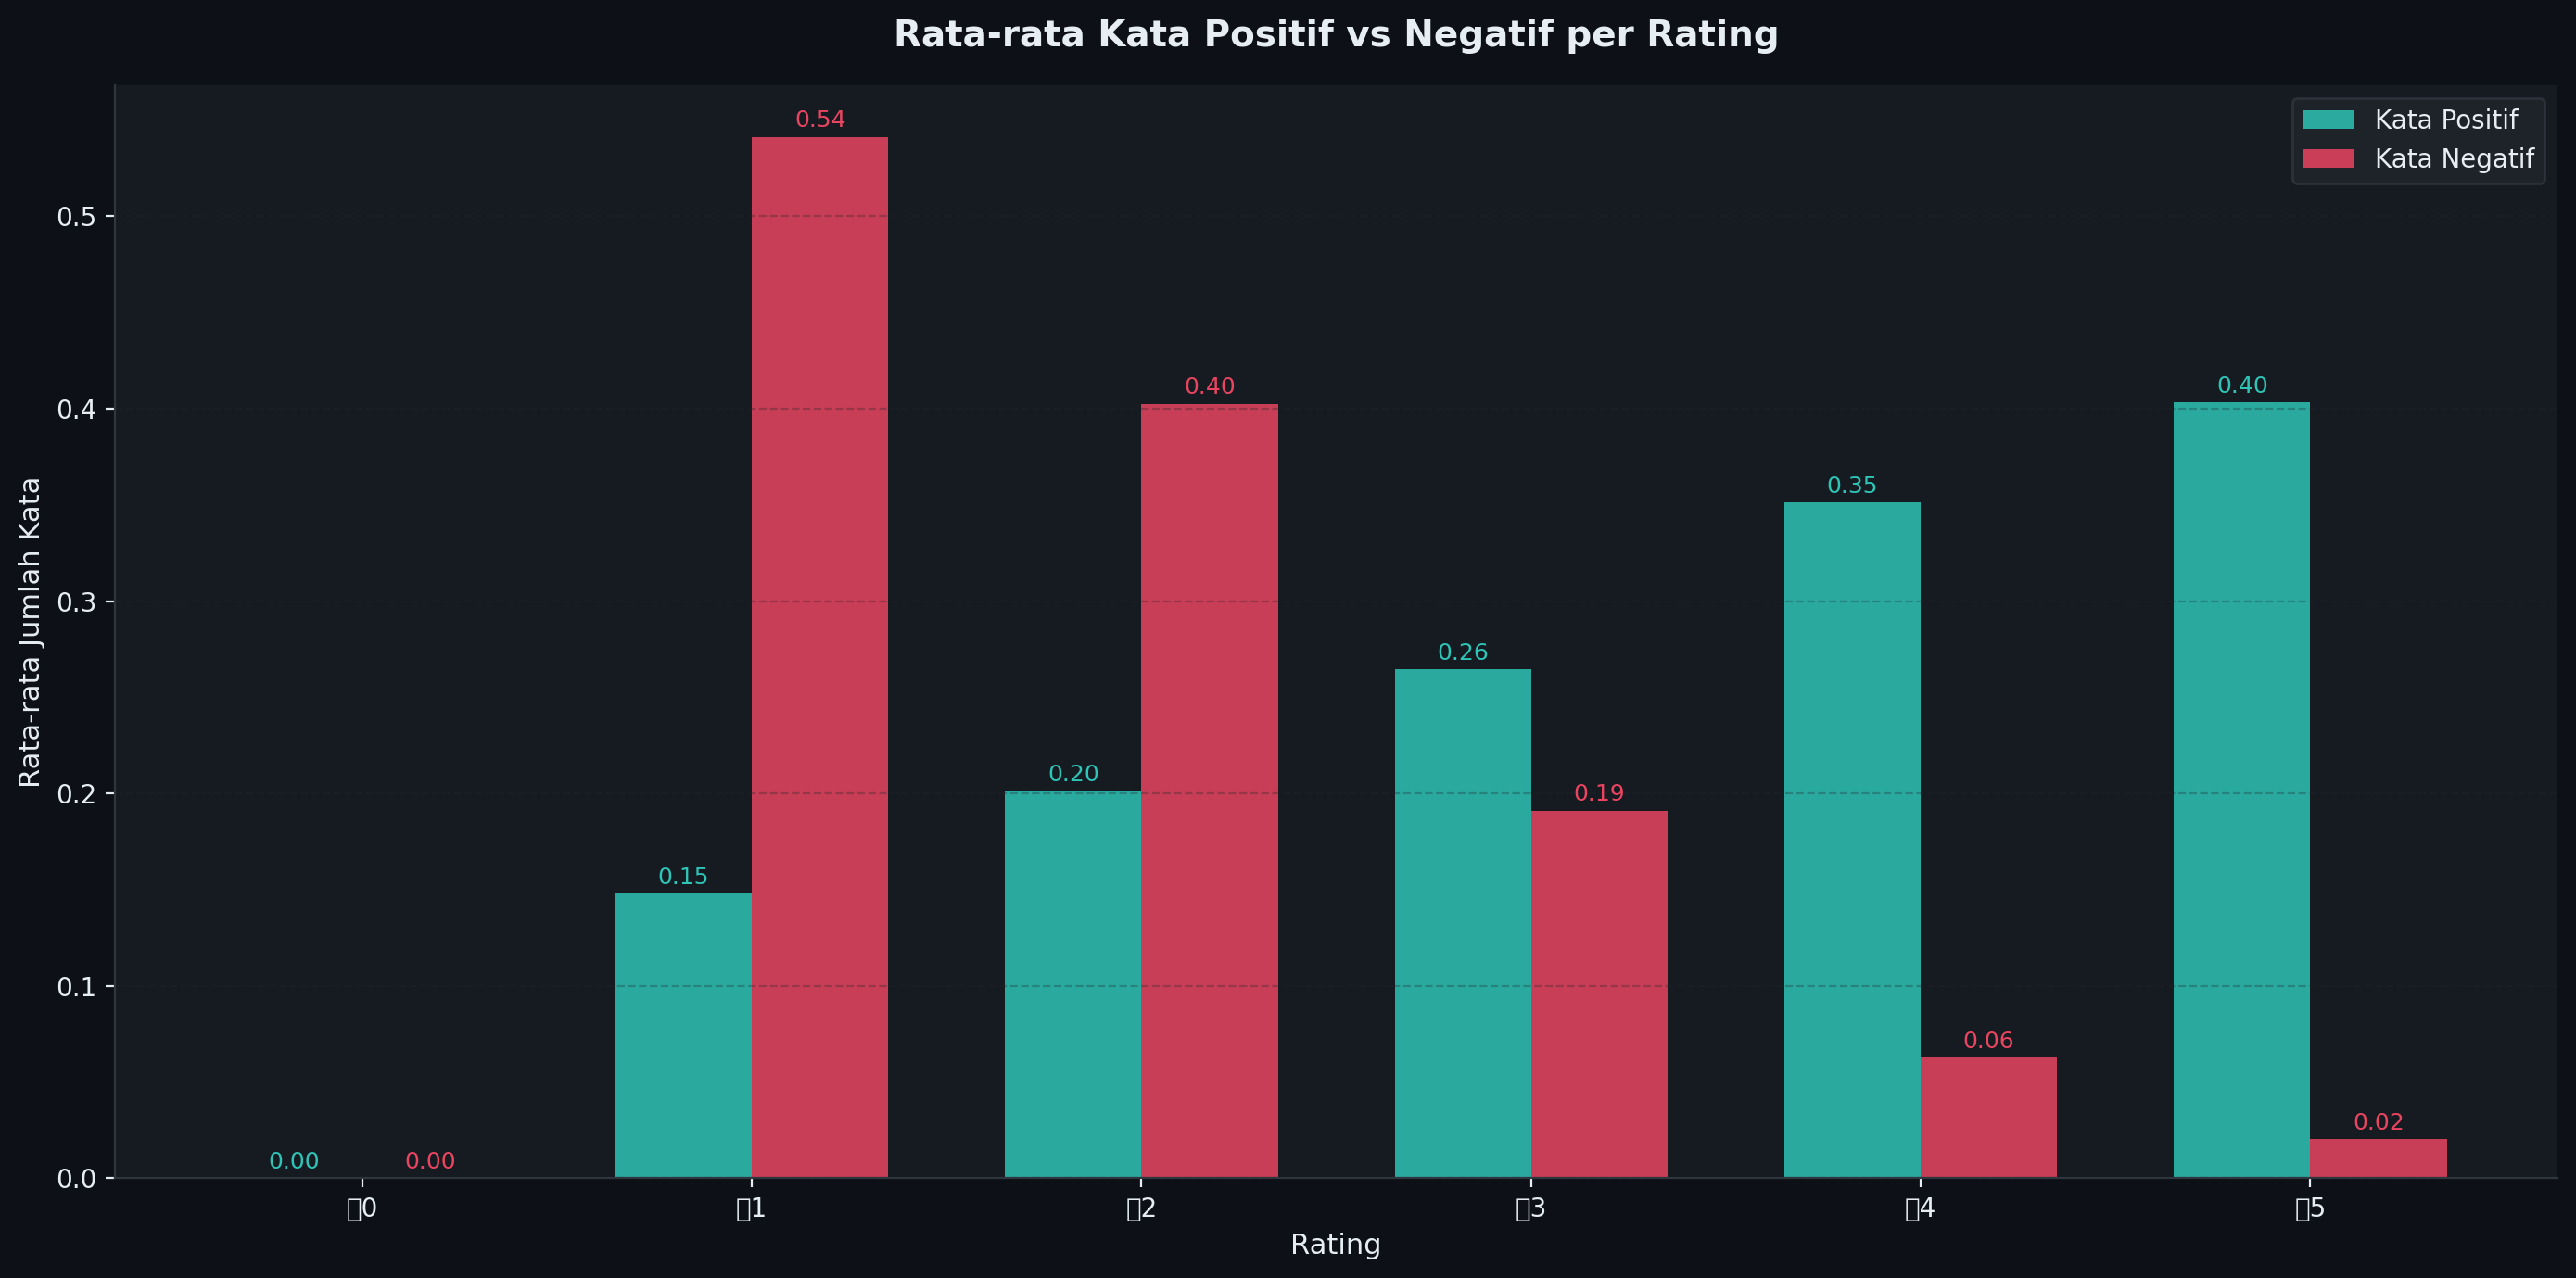

In [15]:
# Kata yang cenderung positif / negatif berdasarkan konteks
positive_keywords = ['bagus','baik','mantap','keren','suka','puas','lancar',
                     'cepat','stabil','mudah','oke','ok','recommended','best','fast']
negative_keywords = ['jelek','lambat','lemot','error','crash','gagal','buruk',
                     'kecewa','susah','parah','lelet','boros','mahal','masalah']

def count_sentiment_words(tokens, keywords):
    return sum(1 for t in tokens if t in keywords)

df_myim3rev['pos_count'] = df_myim3rev['tokens'].apply(
    lambda t: count_sentiment_words(t, positive_keywords))
df_myim3rev['neg_count'] = df_myim3rev['tokens'].apply(
    lambda t: count_sentiment_words(t, negative_keywords))

# Rata-rata per score
sentiment_by_score = df_myim3rev.groupby('score')[['pos_count','neg_count']].mean()

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG_COLOR)

x = np.arange(len(sentiment_by_score))
w = 0.35
bars1 = ax.bar(x - w/2, sentiment_by_score['pos_count'], w,
               label='Kata Positif', color=GREEN, edgecolor='none', alpha=0.85)
bars2 = ax.bar(x + w/2, sentiment_by_score['neg_count'], w,
               label='Kata Negatif', color=ACCENT, edgecolor='none', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, color=GREEN)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.2f}', ha='center', fontsize=9, color=ACCENT)

ax.set_xticks(x)
ax.set_xticklabels([f'⭐{int(s)}' for s in sentiment_by_score.index])
ax.set_title('Rata-rata Kata Positif vs Negatif per Rating', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Rating', fontsize=11)
ax.set_ylabel('Rata-rata Jumlah Kata', fontsize=11)
ax.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor=TEXT_COLOR)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('pos_neg.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()


## 💾 10. Simpan Hasil Preprocessing

In [ ]:
# Simpan ke CSV
output_cols = ['content','content_clean','content_processed','tokens',
               'score','thumbsUpCount','at','token_count','pos_count','neg_count']
output_cols_ok = [c for c in output_cols if c in df_myim3rev.columns]

df_myim3rev[output_cols_ok].to_csv('myim3_preprocessed.csv', index=False)
print("Disimpan ke myim3_preprocessed.csv")
print(f"   Shape: {df_myim3rev[output_cols_ok].shape}")
display(df_myim3rev[output_cols_ok].head(5))


## ✅ Ringkasan Pipeline

| Tahap | Proses | Output |
|-------|--------|--------|
| 1 | Load Dataset | `df_myim3rev` |
| 2 | Text Cleaning | lowercase, hapus URL/simbol/emoji |
| 3 | NLTK Stopwords | 758 kata bawaan |
| 4 | Custom Stopwords | +60 kata gaul/singkatan/EN |
| 5 | Tokenisasi & Filter | token bersih per review |
| 6 | Frekuensi & Visualisasi | grafik bar, heatmap, distribusi |
| 7 | Export | `myim3_preprocessed.csv` |

---
**Next step:** Sentiment Analysis (TF-IDF + Logistic Regression / BERT)
